In [2]:
import math
import cv2
import numpy as np
from time import time
import mediapipe as mp
import matplotlib.pyplot as plt

In [3]:
# Initializing mediapipe pose class.
mp_pose = mp.solutions.pose

# Setting up the Pose function.
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.3, model_complexity=2)

# Initializing mediapipe drawing class, useful for annotation.
mp_drawing = mp.solutions.drawing_utils

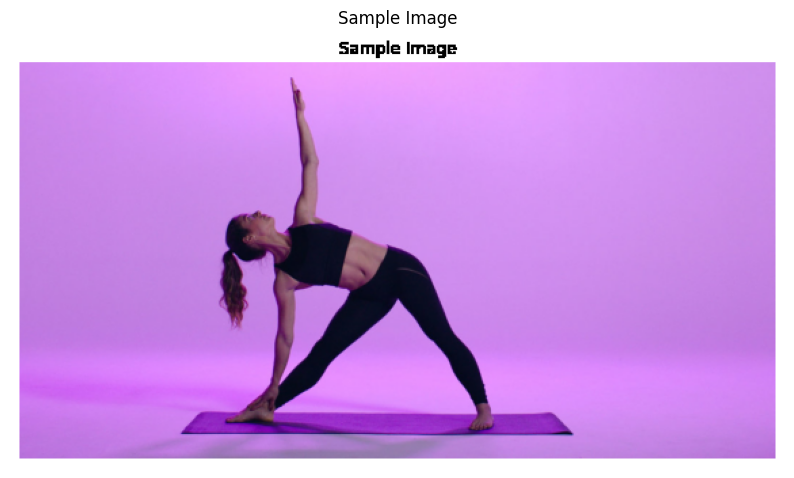

In [3]:
# Read an image from the specified path.
sample_img = cv2.imread("kohli1.jpg")

# Specify a size of the figure.
plt.figure(figsize = [10, 10])

# Display the sample image, also convert BGR to RGB for display. 
plt.title("Sample Image");plt.axis('off');plt.imshow(sample_img[:,:,::-1]);plt.show()

In [4]:
# Perform pose detection after converting the image into RGB format.
results = pose.process(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))

# Check if any landmarks are found.
if results.pose_landmarks:
    
    # Iterate two times as we only want to display first two landmarks.
    for i in range(2):
        
        # Display the found normalized landmarks.
        print(f'{mp_pose.PoseLandmark(i).name}:\n{results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value]}') 

NOSE:
x: 0.3189237117767334
y: 0.41416287422180176
z: -0.15898260474205017
visibility: 0.9999916553497314

LEFT_EYE_INNER:
x: 0.31128236651420593
y: 0.41960784792900085
z: -0.15033495426177979
visibility: 0.9999654293060303



In [5]:
# Retrieve the height and width of the sample image.
image_height, image_width, _ = sample_img.shape

# Check if any landmarks are found.
if results.pose_landmarks:
    
    # Iterate two times as we only want to display first two landmark.
    for i in range(2):
        
        # Display the found landmarks after converting them into their original scale.
        print(f'{mp_pose.PoseLandmark(i).name}:') 
        print(f'x: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].x * image_width}')
        print(f'y: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].y * image_height}')
        print(f'z: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].z * image_width}')
        print(f'visibility: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].visibility}\n')

NOSE:
x: 182.4243631362915
y: 133.36044549942017
z: -90.9380499124527
visibility: 0.9999916553497314

LEFT_EYE_INNER:
x: 178.0535136461258
y: 135.11372703313828
z: -85.99159383773804
visibility: 0.9999654293060303



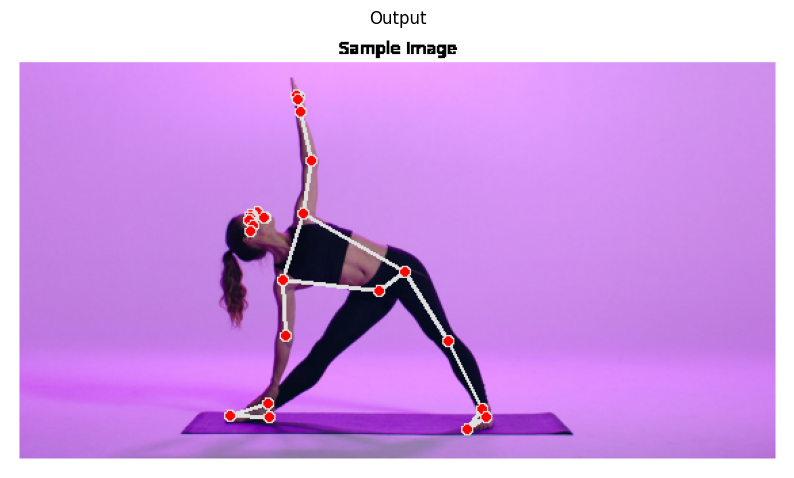

In [6]:
# Create a copy of the sample image to draw landmarks on.
img_copy = sample_img.copy()

# Check if any landmarks are found.
if results.pose_landmarks:
    
    # Draw Pose landmarks on the sample image.
    mp_drawing.draw_landmarks(image=img_copy, landmark_list=results.pose_landmarks, connections=mp_pose.POSE_CONNECTIONS)
       
    # Specify a size of the figure.
    fig = plt.figure(figsize = [10, 10])

    # Display the output image with the landmarks drawn, also convert BGR to RGB for display. 
    plt.title("Output");plt.axis('off');plt.imshow(img_copy[:,:,::-1]);plt.show()

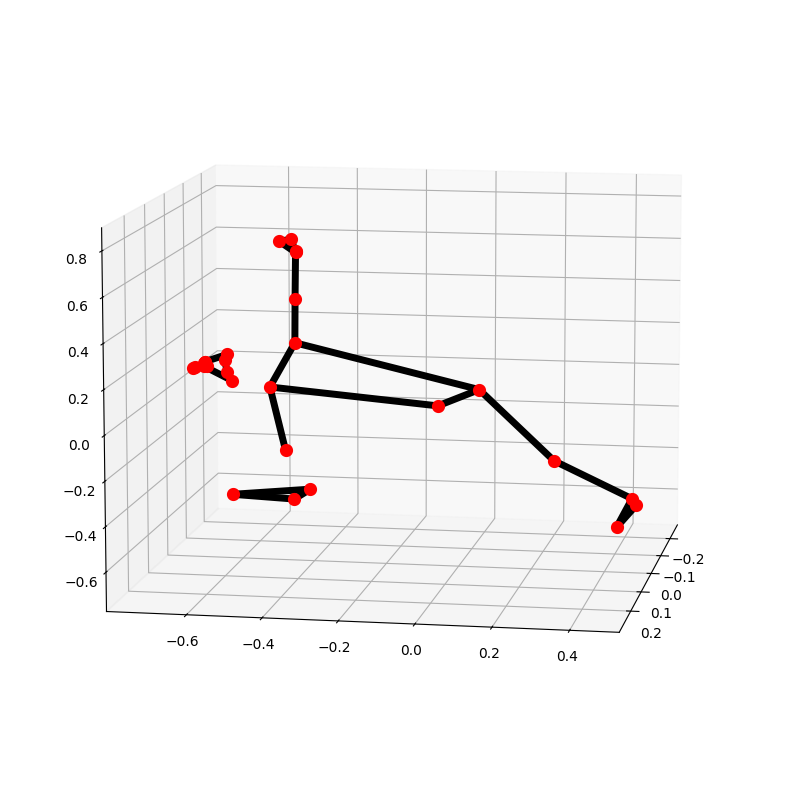

In [7]:
# Plot Pose landmarks in 3D.
mp_drawing.plot_landmarks(results.pose_world_landmarks, mp_pose.POSE_CONNECTIONS)

In [8]:
def detectPose(image, pose, display=True):
    '''
    This function performs pose detection on an image.
    Args:
        image: The input image with a prominent person whose pose landmarks needs to be detected.
        pose: The pose setup function required to perform the pose detection.
        display: A boolean value that is if set to true the function displays the original input image, the resultant image, 
                 and the pose landmarks in 3D plot and returns nothing.
    Returns:
        output_image: The input image with the detected pose landmarks drawn.
        landmarks: A list of detected landmarks converted into their original scale.
    '''
    
    # Create a copy of the input image.
    output_image = image.copy()
    
    # Convert the image from BGR into RGB format.
    imageRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Perform the Pose Detection.
    results = pose.process(imageRGB)
    
    # Retrieve the height and width of the input image.
    height, width, _ = image.shape
    
    # Initialize a list to store the detected landmarks.
    landmarks = []
    
    # Check if any landmarks are detected.
    if results.pose_landmarks:
    
        # Draw Pose landmarks on the output image.
        mp_drawing.draw_landmarks(image=output_image, landmark_list=results.pose_landmarks,
                                  connections=mp_pose.POSE_CONNECTIONS)
        
        # Iterate over the detected landmarks.
        for landmark in results.pose_landmarks.landmark:
            
            # Append the landmark into the list.
            landmarks.append((int(landmark.x * width), int(landmark.y * height),
                                  (landmark.z * width)))
    
    # Check if the original input image and the resultant image are specified to be displayed.
    if display:
    
        # Display the original input image and the resultant image.
        plt.figure(figsize=[22,22])
        plt.subplot(121);plt.imshow(image[:,:,::-1]);plt.title("Original Image");plt.axis('off');
        plt.subplot(122);plt.imshow(output_image[:,:,::-1]);plt.title("Output Image");plt.axis('off');
        
        # Also Plot the Pose landmarks in 3D.
        mp_drawing.plot_landmarks(results.pose_world_landmarks, mp_pose.POSE_CONNECTIONS)
        
    # Otherwise
    else:
        
        # Return the output image and the found landmarks.
        return output_image, landmarks

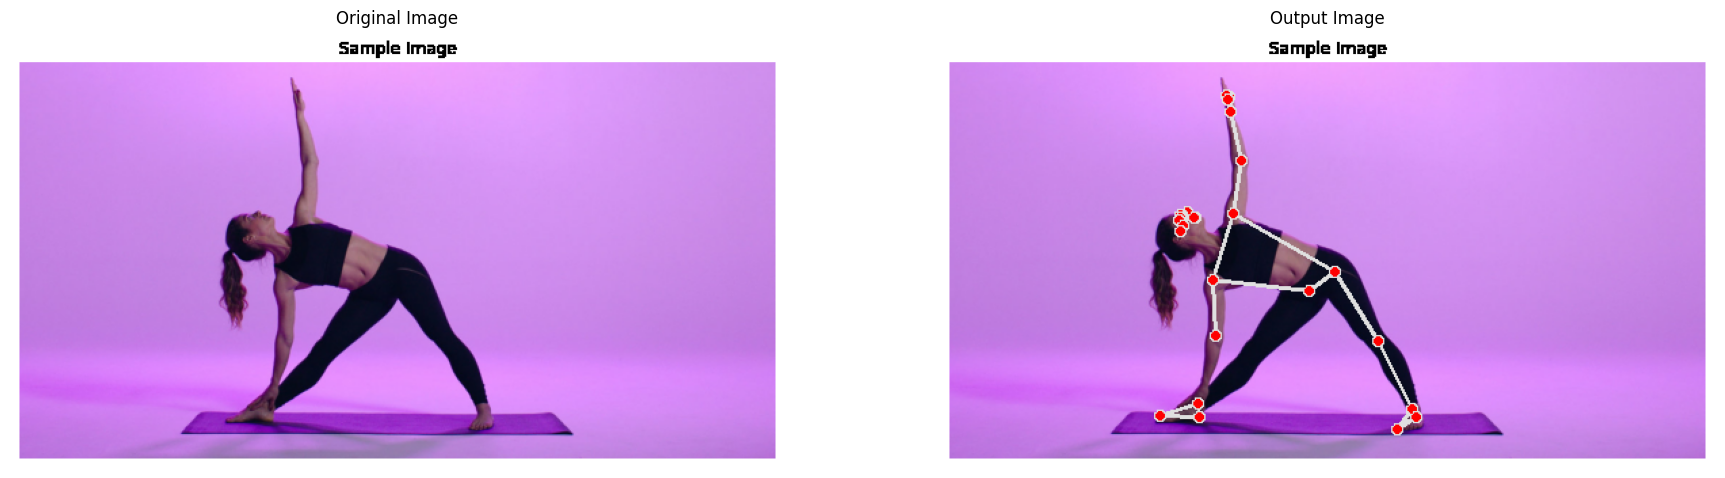

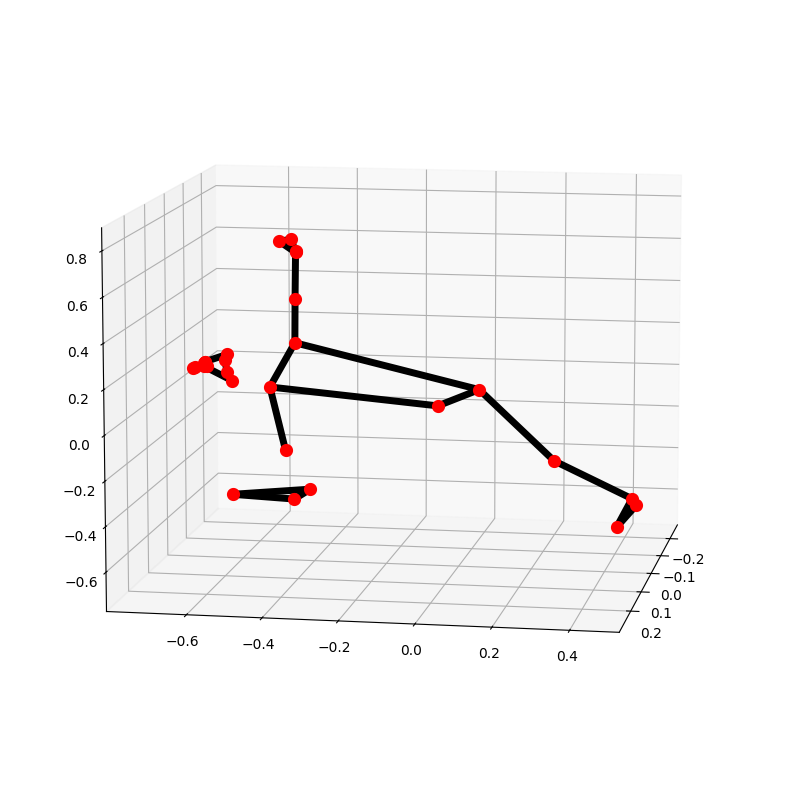

In [11]:
# Read another sample image and perform pose detection on it.
image = cv2.imread('pose2.png')
detectPose(image, pose, display=True)

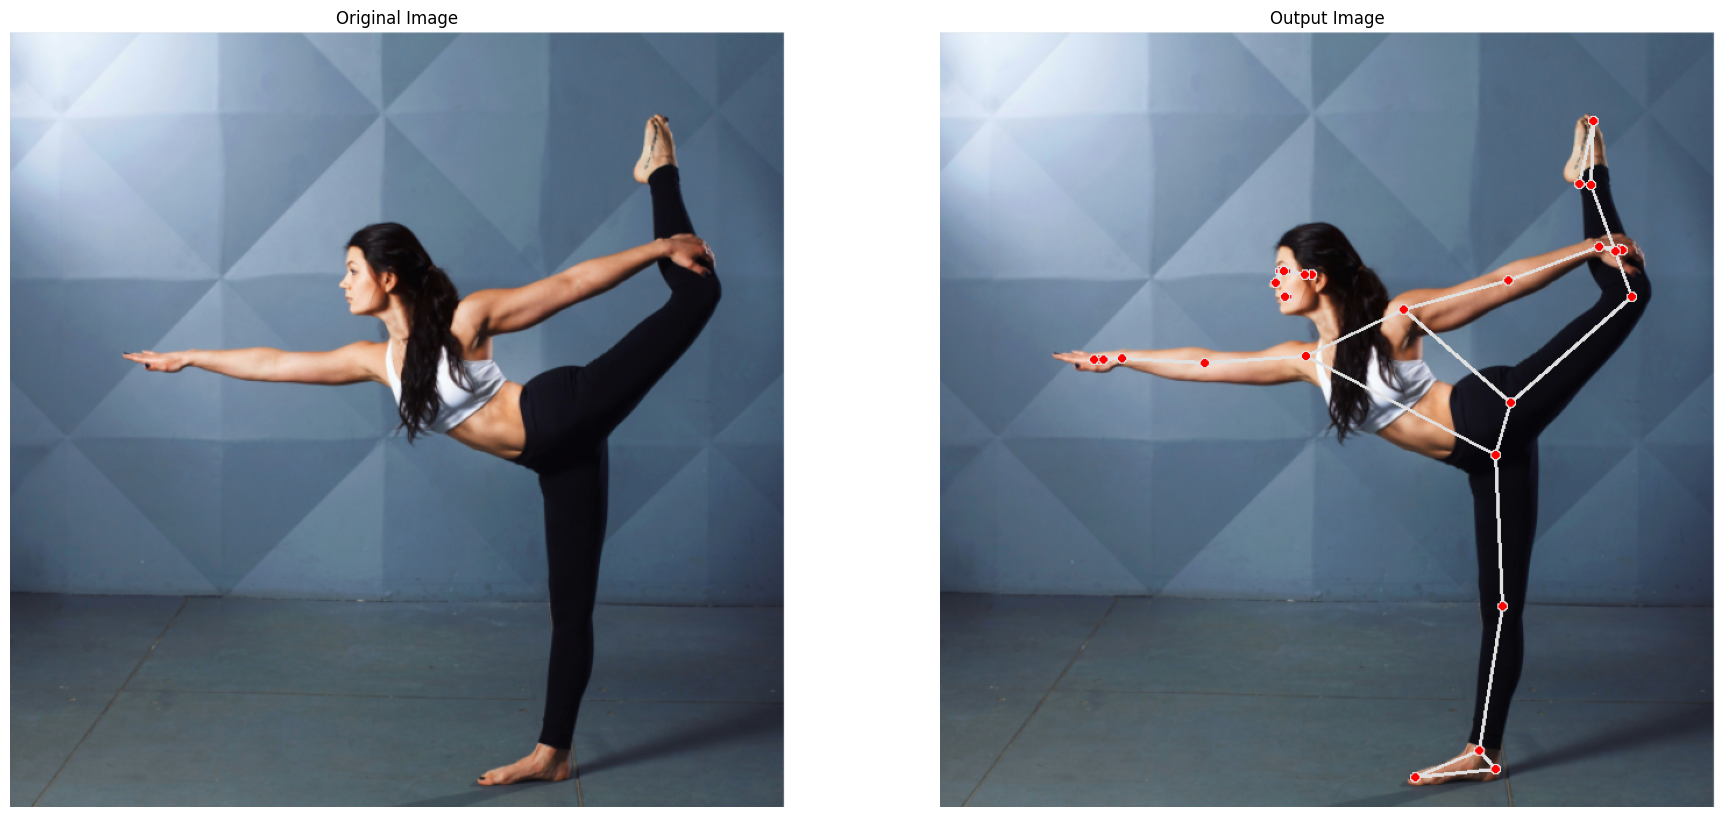

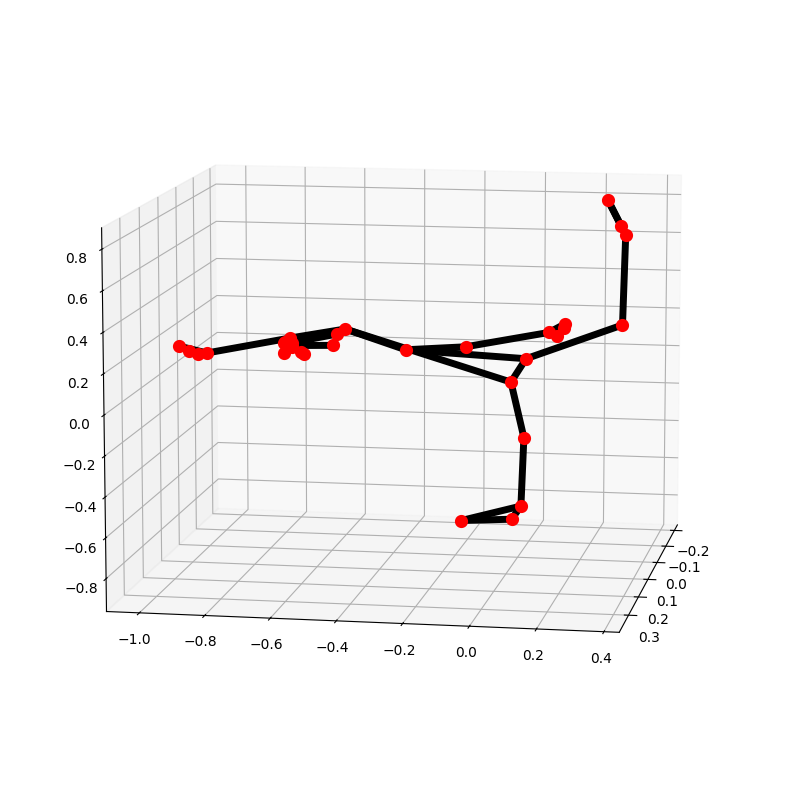

In [12]:
# Read another sample image and perform pose detection on it.
image = cv2.imread('pose3.png')
detectPose(image, pose, display=True)

In [13]:
import cv2
import mediapipe as mp
from time import time

# Function to draw skeleton on the frame
def draw_skeleton(frame, landmarks, connections):
    for connection in connections:
        start_point = landmarks[connection[0]]
        end_point = landmarks[connection[1]]

        # Convert float coordinates to integers
        start_point = (int(start_point[0]), int(start_point[1]))
        end_point = (int(end_point[0]), int(end_point[1]))

        # Draw a line between the two points
        cv2.line(frame, start_point, end_point, (0, 255, 0), 2)

# Setup Pose function for video.
mp_pose = mp.solutions.pose
pose_video = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, model_complexity=1)

# Initialize the VideoCapture object to read from the webcam.
video = cv2.VideoCapture(0)

# Create named window for resizing purposes
cv2.namedWindow('Pose Detection', cv2.WINDOW_NORMAL)

# Set video camera size
video.set(3, 1280)
video.set(4, 960)

# Initialize a variable to store the time of the previous frame.
time1 = 0

# List to store pose data for each frame
pose_data = []

# Specify the connections between body parts for drawing the skeleton
connections = mp_pose.POSE_CONNECTIONS

# Flag to continue visualization even after pressing 'ESC'
continue_visualization = True

while continue_visualization:
    # Read a frame.
    ok, frame = video.read()

    # Check if frame is not read properly.
    if not ok:
        # Break the loop.
        break

    # Flip the frame horizontally for natural (selfie-view) visualization.
    frame = cv2.flip(frame, 1)

    # Get the width and height of the frame
    frame_height, frame_width, _ = frame.shape

    # Resize the frame while keeping the aspect ratio.
    frame = cv2.resize(frame, (int(frame_width * (640 / frame_height)), 640))

    # Perform Pose landmark detection.
    frame, landmarks = detectPose(frame, pose_video, display=False)

    # Check if pose landmarks are detected
    if landmarks:
        # Set the time for this frame to the current time.
        time2 = time()

        # Check if the difference between the previous and this frame time > 0 to avoid division by zero.
        if (time2 - time1) > 0:
            # Calculate the number of frames per second.
            frames_per_second = 1.0 / (time2 - time1)

            # Write the calculated number of frames per second on the frame.
            cv2.putText(frame, 'FPS: {}'.format(int(frames_per_second)), (10, 30), cv2.FONT_HERSHEY_PLAIN, 2, (0, 255, 0), 3)

            # Store the pose data for this frame
            pose_data.append(landmarks)

            # Draw the skeleton on the frame
            draw_skeleton(frame, landmarks, connections)

        # Update the previous frame time to this frame time.
        # As this frame will become the previous frame in the next iteration.
        time1 = time2

        # Display the frame.
        cv2.imshow('Pose Detection', frame)

    # Wait until a key is pressed.
    # Retrieve the ASCII code of the key pressed
    k = cv2.waitKey(1) & 0xFF

    # Check if 'ESC' is pressed.
    if k == 27:
        # Stop capturing motion and exit visualization loop
        continue_visualization = False

# Release the VideoCapture object.
video.release()

# Close the windows.
cv2.destroyAllWindows()

# Now, pose_data contains the pose information for each frame. You can use this data for further analysis or processing.


In [12]:
import cv2
import mediapipe as mp
import numpy as np

# Function to draw skeleton on the frame
def draw_skeleton(frame, landmarks, connections):
    for connection in connections:
        start_point = landmarks[connection[0]]
        end_point = landmarks[connection[1]]

        # Convert float coordinates to integers
        start_point = (int(start_point[0]), int(start_point[1]))
        end_point = (int(end_point[0]), int(end_point[1]))

        # Draw a line between the two points
        cv2.line(frame, start_point, end_point, (0, 255, 0), 2)

# Setup Pose function for video.
mp_pose = mp.solutions.pose
pose_video = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, model_complexity=1)

# Create a blank image for visualization
blank_image = 255 * np.ones((720, 1280, 3), dtype=np.uint8)  # Adjust the size as needed

# Specify the connections between body parts for drawing the skeleton
connections = mp_pose.POSE_CONNECTIONS

# Visualize the captured pose data
for landmarks in pose_data:
    # Create a copy of the blank image for each frame
    frame = blank_image.copy()

    # Draw the skeleton on the frame
    draw_skeleton(frame, landmarks, connections)

    # Display the frame.
    cv2.imshow('Captured Pose Data', frame)

    # Wait for a short duration between frames (adjust as needed)
    cv2.waitKey(30)

# Wait for a key press before closing the window
cv2.waitKey(0)

# Close the windows.
cv2.destroyAllWindows()
